m=  5 | acc=0.80 | iters=50000 | norm=3.93
m=  6 | acc=0.92 | iters=50000 | norm=6.01
m=  7 | acc=1.00 | iters=1874 | norm=3.44
m=  8 | acc=1.00 | iters=1691 | norm=3.33
m=  9 | acc=0.98 | iters=50000 | norm=5.83
m= 10 | acc=0.98 | iters=50000 | norm=5.22
m= 20 | acc=1.00 | iters=1603 | norm=4.06
m= 40 | acc=1.00 | iters= 800 | norm=4.31
m= 80 | acc=1.00 | iters= 814 | norm=5.60
m=160 | acc=1.00 | iters= 547 | norm=7.51
m=320 | acc=1.00 | iters= 346 | norm=10.47


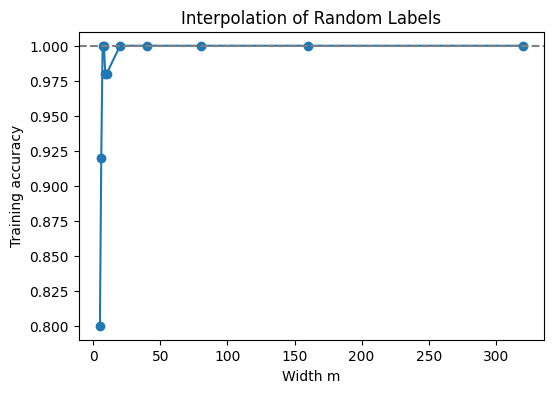

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Reproducibility
# -----------------------------
torch.manual_seed(0)
np.random.seed(0)

# -----------------------------
# Data
# -----------------------------
n = 50          # number of data points
d = 10          # input dimension

X = torch.randn(n, d)
y = torch.randint(0, 2, (n,)) * 2 - 1  # random labels in {-1, +1}
y = y.float().view(-1, 1)

# -----------------------------
# Two-layer ReLU network
# -----------------------------
class TwoLayerReLU(nn.Module):
    def __init__(self, d, m):
        super().__init__()
        self.fc1 = nn.Linear(d, m, bias=False)
        self.fc2 = nn.Linear(m, 1, bias=False)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

    def param_norm(self):
        return torch.sqrt(
            sum(p.pow(2).sum() for p in self.parameters())
        ).item()

# -----------------------------
# Training function
# -----------------------------
def train_model(m, l2_reg=0.0, max_iters=50_000, lr=1e-2):
    model = TwoLayerReLU(d, m)
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=l2_reg)
    loss_fn = nn.MSELoss()

    for it in range(max_iters):
        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            acc = (torch.sign(preds) == y).float().mean().item()
            if acc == 1.0:
                return acc, it + 1, model.param_norm()

    return acc, max_iters, model.param_norm()

# -----------------------------
# Run experiments for increasing widths
# -----------------------------
widths = [5, 6, 7, 8, 9, 10, 20, 40, 80, 160, 320]
accs = []
iters = []
norms = []

for m in widths:
    acc, it, norm = train_model(m)
    accs.append(acc)
    iters.append(it)
    norms.append(norm)
    print(f"m={m:3d} | acc={acc:.2f} | iters={it:4d} | norm={norm:.2f}")

# -----------------------------
# Plot training accuracy vs width
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(widths, accs, marker="o")
plt.axhline(1.0, linestyle="--", color="gray")
plt.xlabel("Width m")
plt.ylabel("Training accuracy")
plt.title("Interpolation of Random Labels")
plt.show()


m=  5 | acc=0.92 | iters=50000 | norm=3.55
m=  6 | acc=1.00 | iters=36803 | norm=4.30
m=  7 | acc=1.00 | iters=2667 | norm=3.36
m=  8 | acc=1.00 | iters=8522 | norm=4.64
m=  9 | acc=1.00 | iters=2043 | norm=3.40
m= 10 | acc=1.00 | iters=3335 | norm=3.67
m= 20 | acc=1.00 | iters=1414 | norm=3.75
m= 40 | acc=1.00 | iters= 946 | norm=4.25
m= 80 | acc=1.00 | iters= 809 | norm=5.40
m=160 | acc=1.00 | iters= 783 | norm=7.05
m=320 | acc=1.00 | iters= 457 | norm=9.94


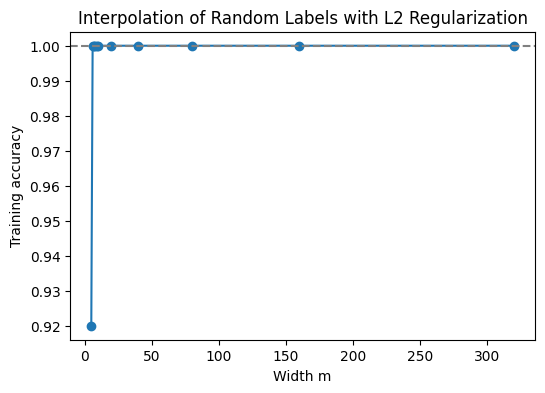

In [4]:
# -----------------------------
# Run experiments for increasing widths
# -----------------------------
widths = [5, 6, 7, 8, 9, 10, 20, 40, 80, 160, 320]
accs = []
iters = []
norms = []

for m in widths:
    acc, it, norm = train_model(m, l2_reg=1e-2)
    accs.append(acc)
    iters.append(it)
    norms.append(norm)
    print(f"m={m:3d} | acc={acc:.2f} | iters={it:4d} | norm={norm:.2f}")

# -----------------------------
# Plot training accuracy vs width
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(widths, accs, marker="o")
plt.axhline(1.0, linestyle="--", color="gray")
plt.xlabel("Width m")
plt.ylabel("Training accuracy")
plt.title("Interpolation of Random Labels with L2 Regularization")
plt.show()
